In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
os.makedirs("outputs", exist_ok=True)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# UNCOMENT to install the country_converter package
!pip install country_converter

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0786.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0344.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0360.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0010.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0211.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0769.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0456.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0253.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0679.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0181.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0774.jpg
/kaggle/input/datasets/kkhandekar/image-dataset/_train/motorbike/motorbike_0

# Part 1: Warmup Exercises
## Setup

In [2]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.6.0+cu124
TorchVision version: 0.21.0+cu124


In [3]:
# to confirm the GPU is really active
torch.cuda.get_device_name(0)

'Tesla T4'

# PyTorch Tensors

## Tensor Question 1

In [4]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)
tensors = {"a": a, "b": b, "c": c}

for name, t in tensors.items():
    print(f"\nTensor {name}:")
    print(t)
    print(f"shape: {t.shape}")
    print(f"dtype: {t.dtype}")
    print(f"device: {t.device}")

# These tensors are currently on the CPU by default. In training, both the model
# weights and the input tensors must be on the SAME device (CPU or GPU).
# If they are not, PyTorch cannot do the math and will raise a device mismatch error.


Tensor a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

Tensor b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

Tensor c:
tensor([1., 1., 1., 1.])
shape: torch.Size([4])
dtype: torch.float32
device: cpu


## Tensor Question 2

In [5]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print(f"sqrt: {torch.sqrt(x)}")
print(f"sum: {x.sum()}")
print(f"mean: {x.mean()}")
print(f"argmax: {x.argmax()}")

# argmax() gives the index of the biggest value.
#In a classifier, that index is the predicted class.

sqrt: tensor([1., 2., 3., 4., 5.])
sum: 55.0
mean: 11.0
argmax: 4


## Tensor Question 3

In [6]:
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# NumPy only works on CPU.
# So a GPU tensor must be moved to CPU before calling .numpy().

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


## Tensor Question 4

In [7]:
t = torch.arange(24).float()

t1 = t.reshape(4, 6)
print(f"shape (4,6): {t1.shape}")

t2 = t.reshape(2, 3, 4)
print(f"shape (2,3,4): {t2.shape}")

# add new dimension at position 0
t3 = t1.unsqueeze(0)
print(f"shape after unsqueeze: {t3.shape}")

# A single image has shape (C, H, W), where C - channels, H - height, W - width
# A model expects (batch_size, C, H, W). 
# unsqueeze(0) adds the batch dimension when we only have one image.

shape (4,6): torch.Size([4, 6])
shape (2,3,4): torch.Size([2, 3, 4])
shape after unsqueeze: torch.Size([1, 4, 6])


## Tensor Question 5

In [9]:
import numpy as np

np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

# NumPy matrix multiplication
np_result = np.matmul(np_a, np_b)
print(f"NumPy result:\n {np_result}")

# PyTorch matrix multiplication
torch_result = torch.matmul(t_a, t_b)
print(f"PyTorch result:\n {torch_result}")

# check match
print("Match:", np.allclose(np_result, torch_result.numpy()))

# Matrix multiplication is the core operation in neural network layers.
# Each layer computes: outputs = inputs * weights + bias
# So it transforms raw data into higher-level features step by step 
# through multiplication + bias + activation.

NumPy result:
 [[19. 22.]
 [43. 50.]]
PyTorch result:
 tensor([[19., 22.],
        [43., 50.]])
Match: True


# Pretrained Models
## Model Question 1

In [10]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ResNet18 has ~11 million parameters. Training it from scratch needed
# over 1 million labeled images and days of GPU time.
# Pretrained weights save all that effort.
# It is very valuable when working with limited time, budget, or small datasets..

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Total parameters:     11,689,512
Trainable parameters: 11,689,512


## Model Question 2

In [11]:
print(model)

# The final layer is named "fc" and its output size is 100.
# which matches the 1000 ImageNet classes the model predicts.

# The blocks layer1–layer4 are the deep feature extractor.
# A network is "deep" because it stacks many layers so it can learn
# more complex patterns step by step.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Model Question 3

In [12]:
model = model.to(device)
model.eval()

print("Model ready for inference.")

# .to(device) moves the model to GPU/CPU so it matches the input tensors.
# model.eval() switches the model to inference mode so layers like BatchNorm
# and Dropout behave correctly. After these two steps, the model is ready.

Model ready for inference.


## Model Question 4

In [13]:
preprocess = weights.transforms()
print(preprocess)

# Resize/crop makes every image the same size the model expects.
# ToTensor() converts the image to a tensor and scales pixels from 0 to 255 to 0–1.
# Normalization adjusts the image using ImageNet's mean and std,
# because the model was trained with those exact values.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


# Running Inference

In [14]:
import random
random.seed(42)

# Kaggle changed the mounted path format 
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
# LABELS = ["Buildings", "Forest", "Glacier", "Mountain", "Sea", "Street"]

# image-loading helper - picks a random image from a given scene class
def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

# Get the ImageNet class labels from the weights metadata — no separate download needed
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## Inference Question 1

In [15]:
from pathlib import Path
import torch
import torch.nn.functional as F

root = Path("/kaggle/input")
print("Datasets available under /kaggle/input:")
for p in root.iterdir():
    print(" -", p.name)

# Top-5 prediction function
def get_top5_predictions(model, preprocess, image, device, class_labels):

    # Step 1: preprocess image + batch dimension + move to device
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: run model
    with torch.no_grad():
        logits = model(input_tensor) # shape: (1, 1000)

    # Step 3: Convert logits -> probabilities
    probs = F.softmax(logits[0], dim=0)

    # Step 4: top 5 predictions
    top_probs, top_indices = probs.topk(5)
    
    # Step 5: build result list of (class_name, probability)
    data = []

    for prob, idx in zip(top_probs, top_indices):
        class_name = class_labels[idx.item()]
        data.append((class_name, prob.item()))

    return data

# test on one mountain image
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# The top prediction often makes sense because ImageNet includes categories like “alp”, “valley”, 
# “lakeside”, and “mountain tent”. Even though Intel’s dataset uses only 6 scene labels, 
# many ImageNet labels still map well to a mountain scene.

Datasets available under /kaggle/input:
 - datasets
 - life-expectancy-who

Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


## Inference Question 2

In [16]:
# run on all 6 classes (top‑3)
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]

    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# The model is usually most confident on forest and sea images 
# because ImageNet contains many similar categories (e.g., “seashore”, “lakeside”, “rainforest”).
# It is least confident on street and buildings, where ImageNet categories are more fine‑grained 
# (e.g., “parking meter”, “street sign”, “church”).
# Pattern: confidence increases when ImageNet has many visually similar classes


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


## Inference Question 3

In [18]:
# logits vs probabilities
img, img_name = load_sample_image("sea")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = F.softmax(logits[0], dim=0)

print(f"Logit range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]} ({probs.max():.4f})")

# Neural networks output logits because they are easier to optimize during training. 
# Softmax is applied only at the end to turn them into probabilities. 
# For filtering low‑confidence predictions, probabilities are easier to interpret 
# because they sum to 1 and show clear confidence levels.

Logit range: min=-4.71, max=9.64
Prob range: min=0.000000, max=0.3792
Probs sum to: 1.000000
Top prediction: seashore (0.3792)


## Inference Question 4

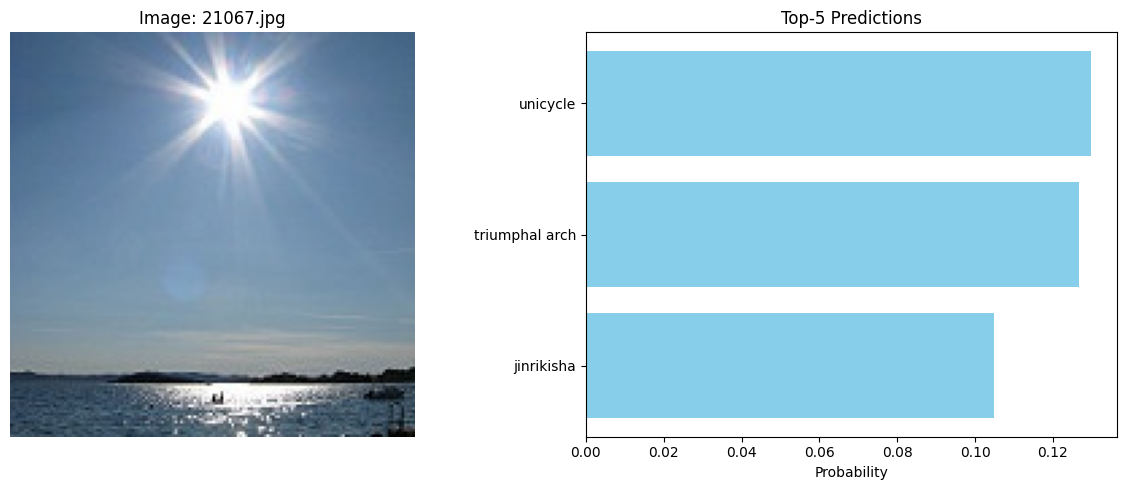

In [20]:
# img, preds, and plt — from the previous questions
classes = [c for c, _ in preds]
probs = [p for _, p in preds]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: image
ax[0].imshow(img)
ax[0].set_title(f"Image: {img_name}")
ax[0].axis("off")

# Right: horizontal bar chart
ax[1].barh(classes, probs, color="skyblue")
ax[1].invert_yaxis()  # highest prob at top
ax[1].set_title("Top-5 Predictions")
ax[1].set_xlabel("Probability")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()


# This visualization makes it easy to see what the model thinks: 
# the image is on the left and the top-5 predicted labels with their probabilities are on the right. 
# For a dashboard used by non‑technical users, I would keep this same layout but make it simpler:
# for example, show only the top‑1 or top‑3 predictions, use clear labels, 
# and color‑code confidence levels so it’s obvious when the model is unsure. 
# A reasonable confidence threshold is around 0.6 for the top‑1 probability; 
# above that the model is usually reliable, 
# and I’d treat it as uncertain instead of using it automatically.
